In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading transaction data...")
train_transaction = pd.read_csv(r'C:\Users\varun\Desktop\fraud-gnn\data\train_transaction.csv')

print("Loading identity data...")
train_identity = pd.read_csv(r'C:\Users\varun\Desktop\fraud-gnn\data\train_identity.csv')

print("✅ Done!")
print(f"Transaction data shape: {train_transaction.shape}")
print(f"Identity data shape: {train_identity.shape}")

Loading transaction data...
Loading identity data...
✅ Done!
Transaction data shape: (590540, 394)
Identity data shape: (144233, 41)


In [2]:
# Look at first 5 rows of transaction data
print("=== TRANSACTION DATA ===")
print(train_transaction.head())

print("\n=== IDENTITY DATA ===")
print(train_identity.head())

print("\n=== FRAUD DISTRIBUTION ===")
print(train_transaction['isFraud'].value_counts())
print(f"\nFraud percentage: {train_transaction['isFraud'].mean()*100:.2f}%")

=== TRANSACTION DATA ===
   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ... V330  V331  V332  V333  V334 V335  \
0    NaN  150.0    discover  142.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
1  404.0  150.0  mastercard  102.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
2  490.0  150.0        visa  166.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
3  567.0  150.0  mastercard  117.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
4  514.0  150.0  mastercard  102.0  ...  0.0   0.0   0.0   0.0   0.0  0.0   

  V336  V337  V338  V339  
0  NaN   NaN   NaN   N

C:\Users\varun\AppData\Local\Temp\ipykernel_29344\1978544685.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='isFraud', data=train_transaction, palette=['#2ecc71','#e74c3c'])


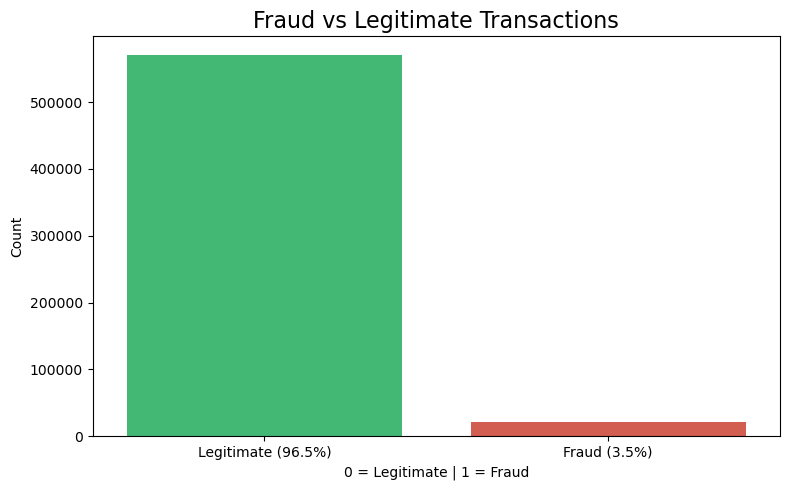

✅ Chart saved!


In [3]:
# Visualize fraud distribution
plt.figure(figsize=(8,5))
sns.countplot(x='isFraud', data=train_transaction, palette=['#2ecc71','#e74c3c'])
plt.title('Fraud vs Legitimate Transactions', fontsize=16)
plt.xlabel('0 = Legitimate | 1 = Fraud')
plt.ylabel('Count')
plt.xticks([0,1], ['Legitimate (96.5%)', 'Fraud (3.5%)'])
plt.tight_layout()
plt.savefig('../notebooks/fraud_distribution.png')
plt.show()
print("✅ Chart saved!")

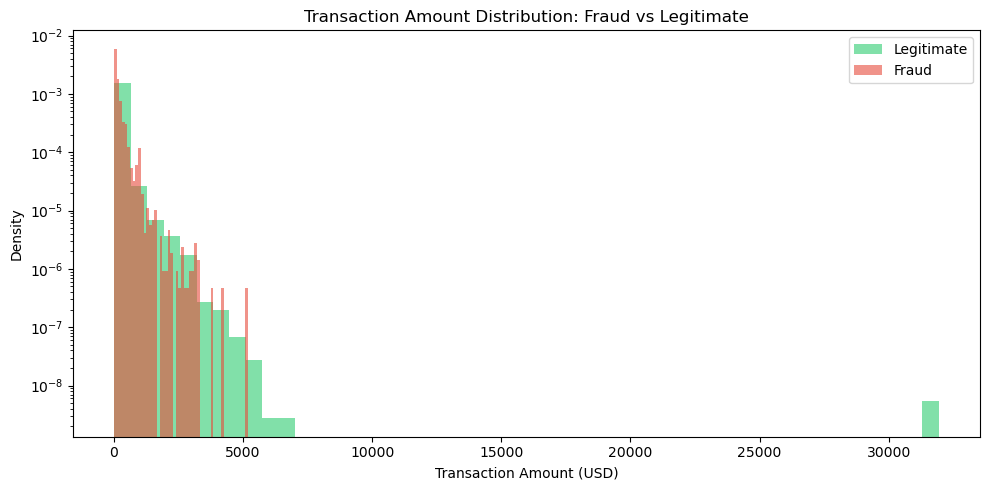

=== AVERAGE TRANSACTION AMOUNT ===
isFraud
0    134.51
1    149.24
Name: TransactionAmt, dtype: float64

=== MEDIAN TRANSACTION AMOUNT ===
isFraud
0    68.5
1    75.0
Name: TransactionAmt, dtype: float64


In [4]:
# Transaction amount analysis
plt.figure(figsize=(10,5))
fraud = train_transaction[train_transaction['isFraud']==1]['TransactionAmt']
legit = train_transaction[train_transaction['isFraud']==0]['TransactionAmt']

plt.hist(legit, bins=50, alpha=0.6, color='#2ecc71', label='Legitimate', density=True)
plt.hist(fraud, bins=50, alpha=0.6, color='#e74c3c', label='Fraud', density=True)
plt.xlabel('Transaction Amount (USD)')
plt.ylabel('Density')
plt.title('Transaction Amount Distribution: Fraud vs Legitimate')
plt.legend()
plt.yscale('log')
plt.tight_layout()
plt.savefig('fraud_amount_distribution.png')
plt.show()

print("=== AVERAGE TRANSACTION AMOUNT ===")
print(train_transaction.groupby('isFraud')['TransactionAmt'].mean().round(2))
print("\n=== MEDIAN TRANSACTION AMOUNT ===")
print(train_transaction.groupby('isFraud')['TransactionAmt'].median().round(2))

In [5]:
# Merge both datasets
df = train_transaction.merge(train_identity, on='TransactionID', how='left')
print(f"Merged dataframe shape: {df.shape}")

# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f"\nColumns with missing values: {len(missing_df)}")
print("\nTop 10 most missing columns:")
print(missing_df.head(10))

# Save merged dataframe
df.to_csv(r'C:\Users\varun\Desktop\fraud-gnn\data\merged_data.csv', index=False)
print("\n✅ Merged data saved!")

Merged dataframe shape: (590540, 434)

Columns with missing values: 414

Top 10 most missing columns:
       Missing Count  Missing %
id_24         585793      99.20
id_07         585385      99.13
id_08         585385      99.13
id_21         585381      99.13
id_26         585377      99.13
id_25         585408      99.13
id_23         585371      99.12
id_27         585371      99.12
id_22         585371      99.12
dist2         552913      93.63


OSError: Cannot save file into a non-existent directory: 'C:\Users\varun\Desktop\fraud-gnn\data'

In [8]:
import os
os.makedirs(r'C:\Users\varun\Desktop\fraud-gnn\data', exist_ok=True)

# Save merged dataframe
df.to_csv(r'C:\Users\varun\Desktop\fraud-gnn\data\merged_data.csv', index=False)
print("✅ Merged data saved!")

✅ Merged data saved!


In [10]:
import os
import pandas as pd

print("Loading original files...")
train_transaction = pd.read_csv(r'C:\Users\varun\Desktop\fraud-gnn\data\train_transaction.csv')
train_identity = pd.read_csv(r'C:\Users\varun\Desktop\fraud-gnn\data\train_identity.csv')

print("Merging...")
df = train_transaction.merge(train_identity, on='TransactionID', how='left')

os.makedirs(r'C:\Users\varun\Desktop\fraud-gnn\data', exist_ok=True)
df.to_csv(r'C:\Users\varun\Desktop\fraud-gnn\data\merged_data.csv', index=False)
print(f"✅ Done! Shape: {df.shape}")

Loading original files...
Merging...
✅ Done! Shape: (590540, 434)
